In [11]:
#Libraries we need

import warnings
warnings.filterwarnings("ignore")

import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os

from rasterio.plot import show
from rasterio.plot import plotting_extent
from rasterio.mask import mask

os.chdir("/home/javi/Documents/ReposGit") #Change to the directory you are working in

In [13]:
def nequalize(array,p=5,nodata=0):
    """
    Normalizes an image or a set of bands of an image using percentile-based histogram equalization.

    Parameters
    ----------
    array : numpy.ndarray
        The image or set of bands to normalize.
    p : float
        The percentile to use for the equalization.
    nodata : float
        The value that represents missing data in the image.

    Returns
    -------
    numpy.ndarray
        The normalized image or set of bands.
    """

    #If the image is a single band: (height, width) simply compute the percentile and normalize
    if len(array.shape)==2:
        vmin=np.percentile(array[array!=nodata],p)
        vmax=np.percentile(array[array!=nodata],100-p)
        eq_array = (array-vmin)/(vmax-vmin)
        eq_array[eq_array>1]=1
        eq_array[eq_array<0]=0
    #If the image has several bands: (number of bands, height, width), does the above but for each band separately
    elif len(array.shape)==3:
        eq_array = np.empty_like(array, dtype=float)
        for i in range(array.shape[0]):
            eq_array[i]=nequalize(array[i], p=p, nodata=nodata)
    return eq_array

In [14]:
def plot_rgb(array, band_list , p = 0, nodata = None, figsize = (12,6), title = None):
    '''
    This function takes as input parameters the array to be plotted,
    a list of indices corresponding to the bands we want to use,
    in the order they should be in (e.g.: [1,2,3]), and an optional
    parameter p, which is the equalization percentile.

    By default it also assigns a figure size of (12,6), which can also be modified.

    Returns only a plot, does not modify the original array.
    Note: array must be an array with these input dimensions: [bands, rows, columns]
    '''
    if not title:
        title = f'Combination {band_list} \n (percentile {p}%)'
        
    img = nequalize(array[band_list], p=p, nodata=nodata)
    plt.figure(figsize = figsize)
    plt.title(title , size = 20)
    show(img)
    plt.show()    
    
#Removes nodata values, defaults to treating them as 0, and normalizes by the reflectance factor
def delNone(array, nodata = 0, factor=10000): 
    return array[array!=nodata]/factor

In [15]:
def firma_espectral_multipoligono(clase, plot = True, color = "k", ecolor = "r", label = ""):
    '''
    This function takes a file with multiple polygons (which must belong to the same class) and computes
    the average spectral signature of all the polygons.
    
    The wavelengths are those of the Sentinel 2 satellite (490nm, 560nm, 665nm, 842nm).
    
    The signature plot is generated by default.
    '''
    for i, shape in enumerate(clase.geometry):
        poligono = shape #geometry of element i of the shp
        extent = poligono.envelope
        s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

        blue = delNone(s2_mask[1],0,10000)
        green = delNone(s2_mask[2],0,10000)
        red = delNone(s2_mask[3],0,10000)
        nir = delNone(s2_mask[7],0,10000)  # Blue=1, Green=2, Red=3, NIR=7 in this 11-band stack

        [mean_b, mean_g, mean_r, mean_nir] = [np.mean(blue), np.mean(green), np.mean(red), np.mean(nir)]
        [std_b, std_g, std_r, std_nir] = [np.std(blue), np.std(green), np.std(red), np.std(nir)]

        if i==0:
            medias = [mean_b, mean_g, mean_r, mean_nir]
            stds = np.asarray([std_b, std_g, std_r, std_nir])
        else:
            medias = [(medias[0]+mean_b)/2, (medias[1]+mean_g)/2, (medias[2]+mean_r)/2, (medias[3]+mean_nir)/2]
            stds = np.asarray([(stds[0]+std_b)/2, (stds[1]+std_g)/2, (stds[2]+std_r)/2, (stds[3]+std_nir)/2])

        long = [490, 560, 665, 842]

    if plot == True:
        plt.errorbar(long, medias, marker = 'o', yerr = stds, elinewidth = 1, ls = '-.', color = color, ecolor = ecolor, capsize=7,label=label)
        plt.legend()

In [64]:
# resolucion = '20m'
# path = 'Imagenes enero 2021/S2B_MSIL2A_20210117T141739_N0214_R010_T20JLL_20210117T182721.SAFE/GRANULE/L2A_T20JLL_A020199_20210117T142741/IMG_DATA/R'+resolucion+'/'
# r = rasterio.open(path+'T20JLL_20210117T141739_B04_'+resolucion+'.jp2').read()
# g = rasterio.open(path+'T20JLL_20210117T141739_B03_'+resolucion+'.jp2').read()
# b = rasterio.open(path+'T20JLL_20210117T141739_B02_'+resolucion+'.jp2').read()

# rgb = np.asarray([r[0],g[0],b[0]])

In [41]:
# print(rgb.shape)

(3, 10980, 10980)


In [66]:
# s2_bandas = rgb

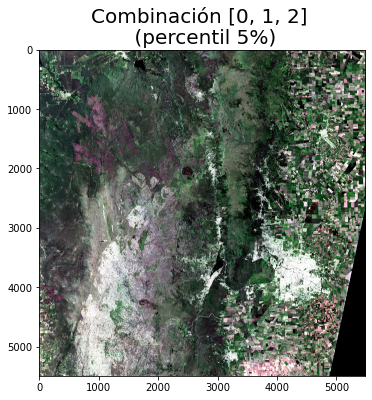

In [65]:
# plot_rgb(rgb,[0,1,2], p=5)

In [4]:
#directory where the image is located
s2 = rasterio.open('ImagenesSentinel/Sur_20mTODOS.tif') #Bands 2,3,4 and 8 
s2_bandas = s2.read()
s2_bandas.shape #(number of bands, image height, image width)

(9, 10980, 10980)

In [5]:
#Coordinate system
print(s2.crs)

#Extent:
print(s2.bounds)

EPSG:32720
BoundingBox(left=300000.0, bottom=6390220.0, right=409800.0, top=6500020.0)


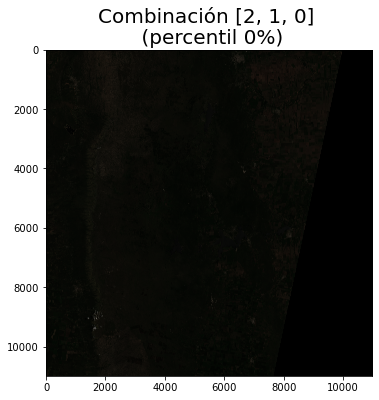

In [6]:
plot_rgb(s2_bandas, [3,2,1], p=0) #Plots the selected bands (indexing starts at 0: 3=Red, 2=Green, 1=Blue), with 5% percentile

In [5]:
radios = gpd.read_file('Poligonos/Embalses_unificado.shp')#.set_index('id') #Loads shp file
radios.drop(columns=['path', 'objeto','entidad','layer'], inplace = True)
radios['id'] = np.linspace(0,10,11).astype(int)
radios.set_index('id')

,gid,fna,Superficie,geometry
id,,,,
0,33857,Cerro Pelado,12.50,"POLYGON ((344214.773 6437426.358, 344209.609 6..."
1,30894,Los Molinos,19.40,"POLYGON ((352710.323 6479131.072, 352714.094 6..."
2,33861,Rio Tercero,46.44,"POLYGON ((365970.151 6439668.417, 365953.147 6..."
3,33879,Pichanas,4.09,"POLYGON ((291335.467 6578390.734, 291299.608 6..."
4,33880,Cruz del Eje,10.29,"POLYGON ((332232.611 6595717.129, 332232.269 6..."
5,33882,La ViÃ±a,5.67,"POLYGON ((307311.654 6472607.890, 307115.235 6..."
6,33884,Usina 3,2.67,"POLYGON ((375123.493 6437419.686, 375060.939 6..."
7,33885,Piedra Mora,8.75,"POLYGON ((375880.378 6437539.201, 375741.044 6..."
8,7814,San Roque,13.30,"POLYGON ((362251.484 6527725.212, 362201.415 6..."


In [7]:
radios.crs #shp metadata

<Derived Projected CRS: EPSG:32720>
Name: WGS 84 / UTM zone 20S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 66°W and 60°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Falkland Islands (Malvinas). Paraguay.
- bounds: (-66.0, -80.0, -60.0, 0.0)
Coordinate Operation:
- name: UTM zone 20S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
Norte = ['Cruz del Eje','San Roque','El Cajon']
Sur = ['Cerro Pelado','Los Molinos','Rio Tercero','La ViÃ±a','Usina 3','Piedra Mora','Arroyo Corto']

radiosN = radios.query('fna in @Norte')
radiosS = radios.query('fna in @Sur')
radiosS

,gid,fna,Superficie,geometry,id
0,33857,Cerro Pelado,12.50,"POLYGON ((344214.773 6437426.358, 344209.609 6...",0
1,30894,Los Molinos,19.40,"POLYGON ((352710.323 6479131.072, 352714.094 6...",1
2,33861,Rio Tercero,46.44,"POLYGON ((365970.151 6439668.417, 365953.147 6...",2
5,33882,La ViÃ±a,5.67,"POLYGON ((307311.654 6472607.890, 307115.235 6...",5
6,33884,Usina 3,2.67,"POLYGON ((375123.493 6437419.686, 375060.939 6...",6
7,33885,Piedra Mora,8.75,"POLYGON ((375880.378 6437539.201, 375741.044 6...",7
9,33856,Arroyo Corto,3.33,"POLYGON ((351787.950 6434661.122, 351798.854 6...",9


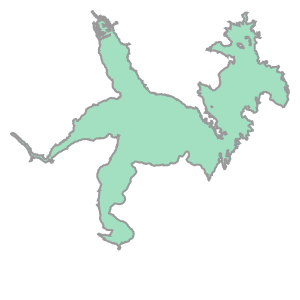

In [7]:
IDEmbalse = 2
nombre = radios.loc[IDEmbalse].fna
poligono = radios.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
poligono

In [8]:
s2_plot_extent = plotting_extent(s2) #Bounds of the region to plot
s2_plot_extent

(300000.0, 409800.0, 6390220.0, 6500020.0)

In [9]:
# Plot of the image with the polygons on top

bandasPosicion = [3,2,1] #North (Red, Green, Blue)
bandasPosicion = [3,2,1] #SOUTH (Red, Green, Blue)


# img = nequalize(s2_bandas[bandasPosicion], p=5, nodata = None)
# fig, ax = plt.subplots(figsize = (15,8))
# show(img, ax=ax, extent = s2_plot_extent, cmap = 'gray')
# radiosS.boundary.plot(ax=ax, edgecolor = 'red')
# plt.show()

<AxesSubplot:>

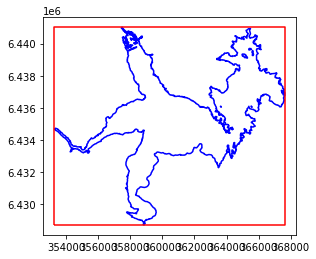

In [10]:
# CROP THE AREA OF INTEREST
extent = poligono.envelope

data = [poligono, extent]
gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

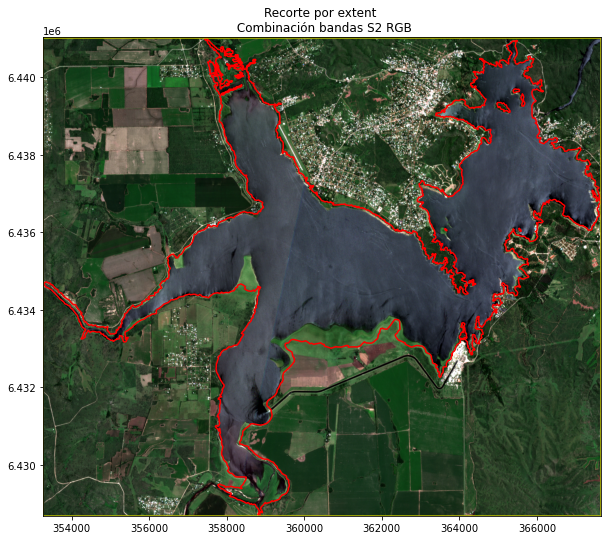

In [11]:
s2_clip, clip_transform = mask(dataset = s2, shapes = [extent], crop = True)
fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_clip[[3,2,1]],p=0.5,nodata = None), ax=ax, transform=clip_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by extent \n S2 RGB band combination")
plt.show()

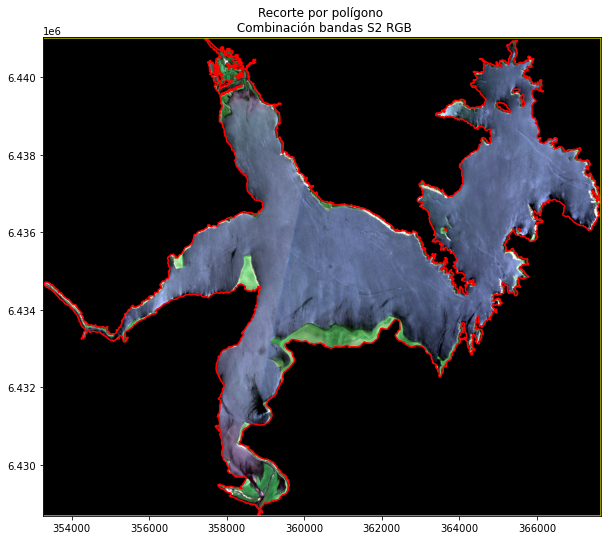

In [12]:
# Keep only what's inside the vector mask
s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_mask[bandasPosicion], p=0.5), ax=ax,transform=mask_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

In [41]:
# s2_rgb = s2_mask[[3,2,1]]/10000
# s2_rgb = s2_rgb[s2_rgb!=0]

# plt.hist(s2_rgb.flatten(), 100); 

In [13]:
reescalado = 10000

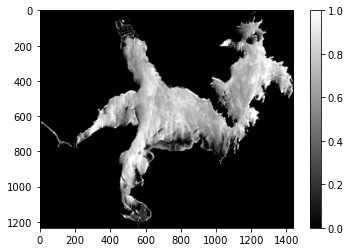

In [14]:
s2_mono = s2_mask[0]/reescalado
plt.imshow(nequalize(s2_mono, p = 5), cmap='gray')
plt.colorbar()

-----------------
Spectral signatures
---------------

In [15]:
blue = delNone(s2_mask[1],0,reescalado)   # Blue is band index 1
green = delNone(s2_mask[2],0,reescalado)  # Green is band index 2
red = delNone(s2_mask[3],0,reescalado)    # Red is band index 3
nir = delNone(s2_mask[7],0,reescalado)    # NIR is band index 7

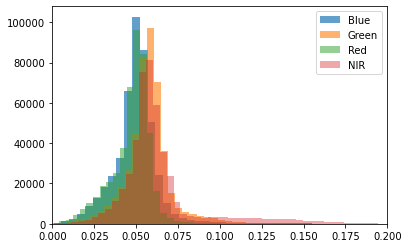

In [16]:
plt.hist(blue, 100, alpha = 0.7, label = 'Blue');
plt.hist(green, 100, alpha = 0.6, label = 'Green');
plt.hist(red, 100, alpha = 0.5, label = 'Red');
plt.hist(nir, 100, alpha = 0.4, label = 'NIR');
plt.xlim(0,0.2)
plt.legend()

In [17]:
#Calculates means and standard deviation for each band

[mean_b, mean_g, mean_r, mean_nir] = [np.mean(blue), np.mean(green), np.mean(red), np.mean(nir)]
[std_b, std_g, std_r, std_nir] = [np.std(blue), np.std(green), np.std(red), np.std(nir)]

medias = [mean_b, mean_g, mean_r, mean_nir]
stds = np.asarray([std_b, std_g, std_r, std_nir])
# stds = np.asarray([std_b, std_g, std_r, std_nir])/(nir.shape[0]) 

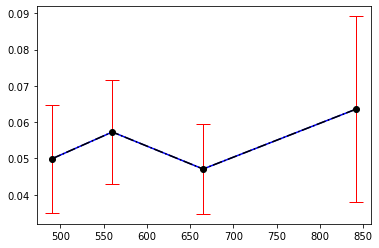

In [18]:
long = [490, 560, 665, 842]

#Perhaps the statistical error should be used instead of the standard deviation as the error
plt.errorbar(long, medias, marker = 'o', yerr = stds, elinewidth = 1, ls = '-.', color = 'k', ecolor = 'red', capsize=7)
plt.plot(long, medias, 'b')


In [19]:
means = []
desvs = []
for i in range(len(s2_mask)):
    aux = delNone(s2_mask[i],0,reescalado)
    means.append(np.mean(aux))
    desvs.append(np.std(aux))#/np.sqrt(len(aux)))
    
means = np.asarray(means)
desvs = np.asarray(desvs)

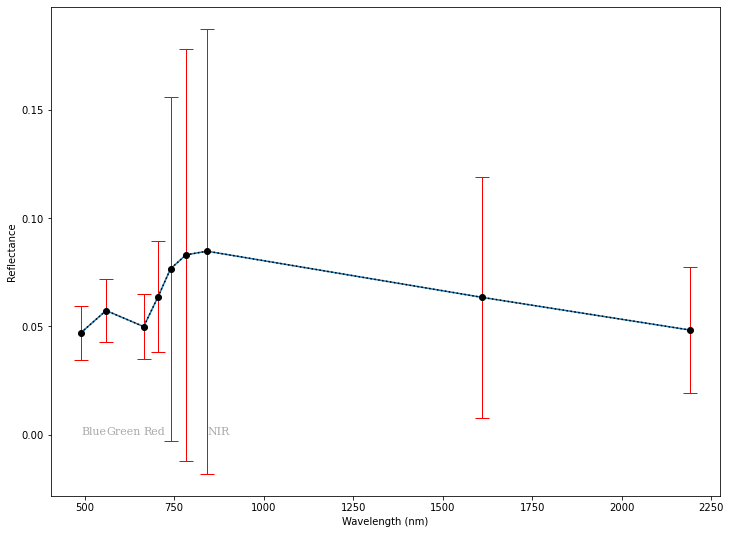

In [20]:
# Wavelengths (nm) matching this stack's actual band order:
# Band1, Blue, Green, Red, Band5, Band6, Band7, NIR, Band9, SWIR1, SWIR2
long = [443, 490, 560, 665, 705, 740, 783, 842, 945, 1610, 2190]


plt.figure(figsize = (12,9))
plt.errorbar(long, means, marker = 'o', yerr = desvs, elinewidth = 1, ls = 'dotted', color = 'k', ecolor = 'red', capsize=7)
plt.plot(long, means)#, label=l)
# plt.fill_between(long, means-desvs, (means+desvs), color='b', alpha=.1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')

font = {'family':'serif', 'color':'darkgray', 'size':11}
for x,t in zip([490, 560, 665, 842], ['Blue','Green','Red','NIR']):
    plt.text(x-0.012, 0, t, fontdict=font)
    
plt.savefig('Firma_SanRoque.png', dpi = 300)

In [21]:
def guardar_GTiff(fn, crs, transform, mat, meta=None, nodata=None, bandnames=[]):
    if len(mat.shape)==2:
        count=1
    else:
        count=mat.shape[0]

    if not meta:
        meta = {}

    meta['driver'] = 'GTiff'
    meta['height'] = mat.shape[-2]
    meta['width'] = mat.shape[-1]
    meta['count'] = count
    meta['crs'] = crs
    meta['transform'] = transform

    if 'dtype' not in meta: #if no datatype is specified, use float32
        meta['dtype'] = np.float32
    

    if nodata==None:
        pass
    else:
        meta['nodata'] = nodata

    with rasterio.open(fn, 'w', **meta) as dst:
        if count==1: #it's a 2D matrix, save it
            dst.write(mat.astype(meta['dtype']), 1)
            if bandnames:
                dst.set_band_description(1, bandnames[0])
        else: #it's a 3D matrix, save each band
            for b in range(count):
                dst.write(mat[b].astype(meta['dtype']), b+1)
            for b,bandname in enumerate(bandnames):
                dst.set_band_description(b+1, bandname)#   
                

In [84]:
#Uncomment to save 
# guardar_GTiff('Procesados/S2_mask.tif', s2.crs, mask_transform, s2_mask, meta = {'dtype': 'uint16', 'nodata': 0})

-----------------------
Indices
--------

In [22]:
#Calculate NDVI
def ndvi(array, bandaR, bandaNIR, factor): 
    red = np.asarray(array[bandaR])/factor
    nir = np.asarray(array[bandaNIR])/factor
    
    return (nir-red)/(nir+red)

#Calculate NDWI
def ndwi(array, bandaG, bandaNIR,factor): 
    green = np.asarray(array[bandaG])/factor
    nir = np.asarray(array[bandaNIR])/factor
    
    return (green - nir)/(nir+green)

def indice(array, banda1, banda2, factor): #the first band is the one being added in the numerator
    aux1 = np.asarray(array[banda1])/factor
    aux2 = np.asarray(array[banda2])/factor
    
    return (aux1-aux2)/(aux1+aux2)

In [20]:
bandasPosicion[2]

0

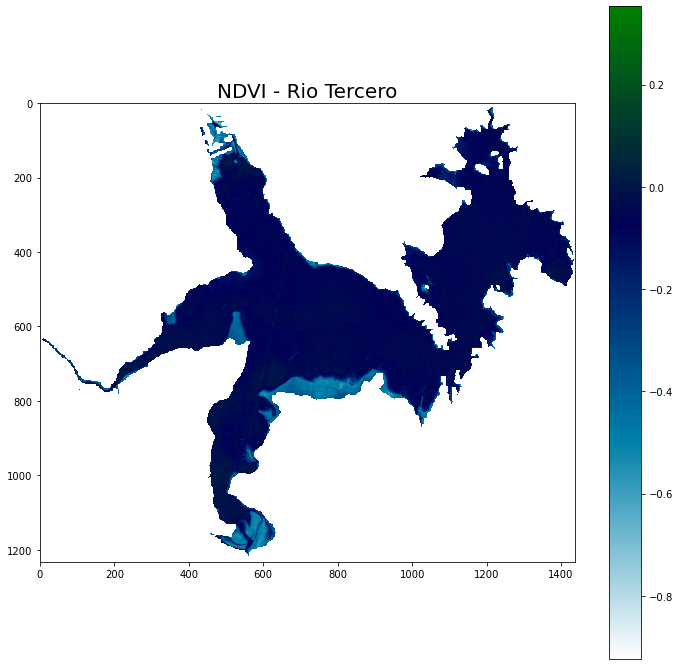

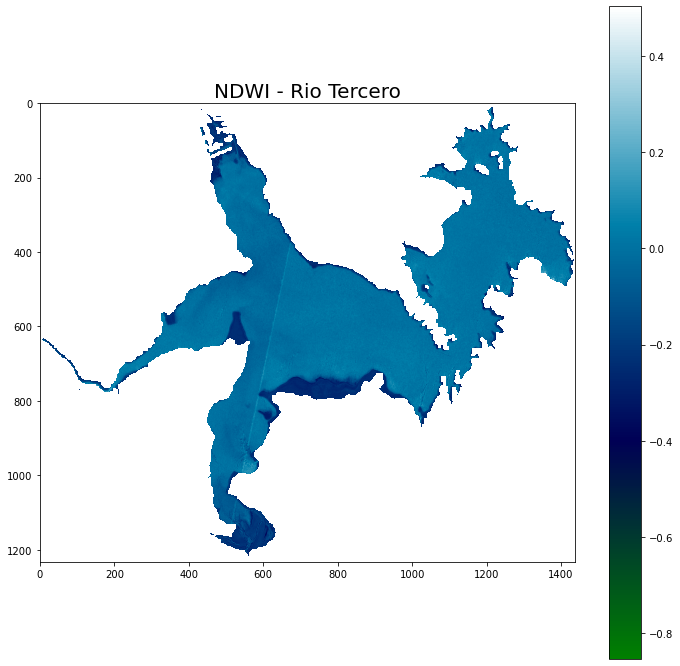

In [37]:
os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
# Documentos Facultad - Conicet/Cursos/Tele - UNSAM/Scipts/Plots
plt.figure(figsize=(12,12))
plt.imshow(ndvi(s2_mask,3,7, 10000), cmap='ocean_r')  # Red=3, NIR=7
plt.colorbar()
plt.title('NDVI - '+nombre,  fontsize = 20)

plt.savefig('Plots/ndvi_'+nombre+'.png', dpi = 300)

plt.figure(figsize=(12,12))
plt.imshow(ndwi(s2_mask,bandasPosicion[1],7,10000), cmap='ocean')  # Green=bandasPosicion[1], NIR=7
plt.colorbar()
plt.title('NDWI - '+nombre,  fontsize = 20)

plt.savefig('Plots/ndwi_'+nombre+'.png', dpi = 300)

os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

In [23]:
indicesTC = [1,2,3,7,9,10]#North (Blue, Green, Red, NIR, SWIR1, SWIR2)
indicesTC = [1,2,3,7,9,10]#South (Blue, Green, Red, NIR, SWIR1, SWIR2)
matriz = []
matriz2 = []
coeficientesS2 = [[-0.3037, 0.2793, 0.4743, 0.5585, 0.5082, 0.1863],
                  [-0.2848, -0.2435, -0.5436, 0.7243, 0.0840, -0.1800],
                  [-0.1509, 0.1973, 0.3279, 0.3406, -0.7112, -0.4572]] 

for i in indicesTC:
    matriz.append(s2_clip[i]/reescalado)
    matriz2.append(s2_mask[i]/reescalado)
    
[brillo, verdor, humedad] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz)
[brilloM, verdorM, humedadM] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz2)

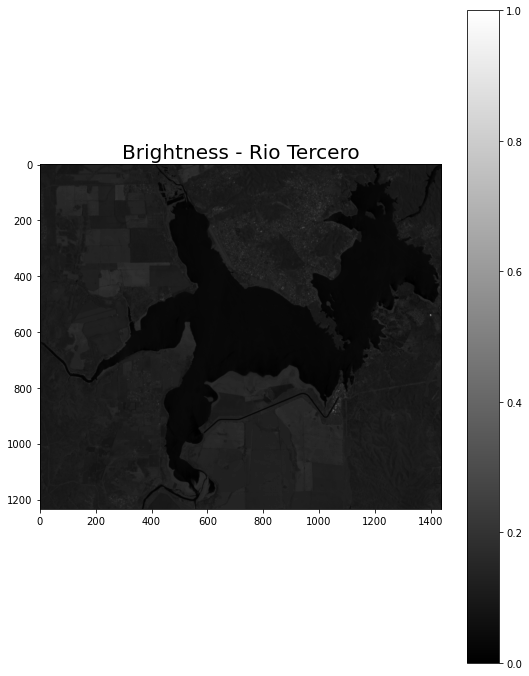

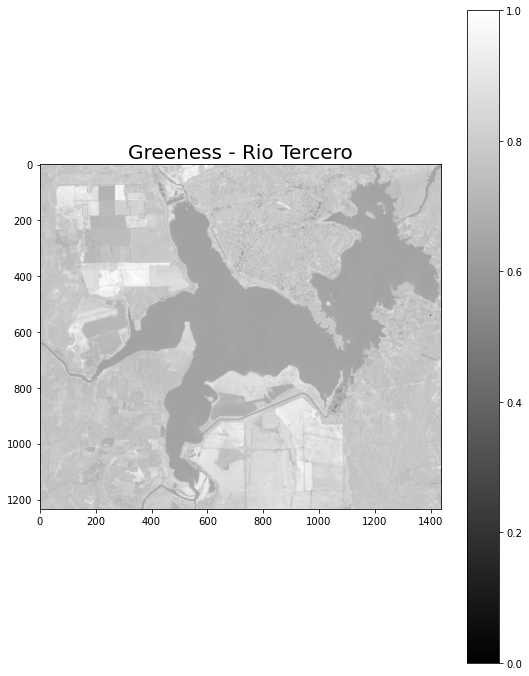

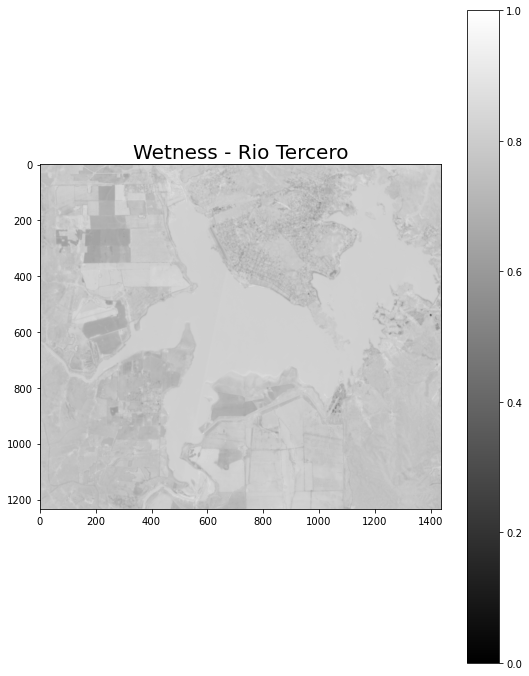

In [ ]:
# os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
# nombre += '-mask'

plt.figure(figsize = (9,12))
plt.imshow(nequalize(brillo,0,0.1), cmap='gray')
plt.colorbar()
plt.title('Brightness - '+nombre,  fontsize = 20)
plt.savefig('Plots/Brightness_'+nombre+'.png', dpi = 300)

plt.figure(figsize = (9,12))
plt.imshow(nequalize(verdor,0,0.1), cmap='gray')
plt.colorbar()
plt.title('Greeness - '+nombre,  fontsize = 20)
plt.savefig('Plots/Greeness_'+nombre+'.png', dpi = 300)

plt.figure(figsize = (9,12))
plt.imshow(nequalize(humedad,0,0.1), cmap='gray')
plt.colorbar()
plt.title('Wetness - '+nombre,  fontsize = 20)
plt.savefig('Plots/Wetness_'+nombre+'.png', dpi = 300)

# os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

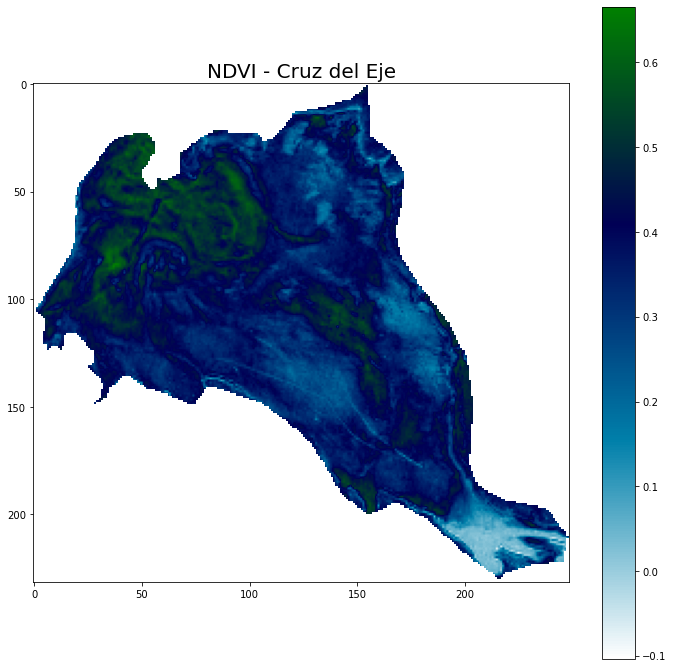

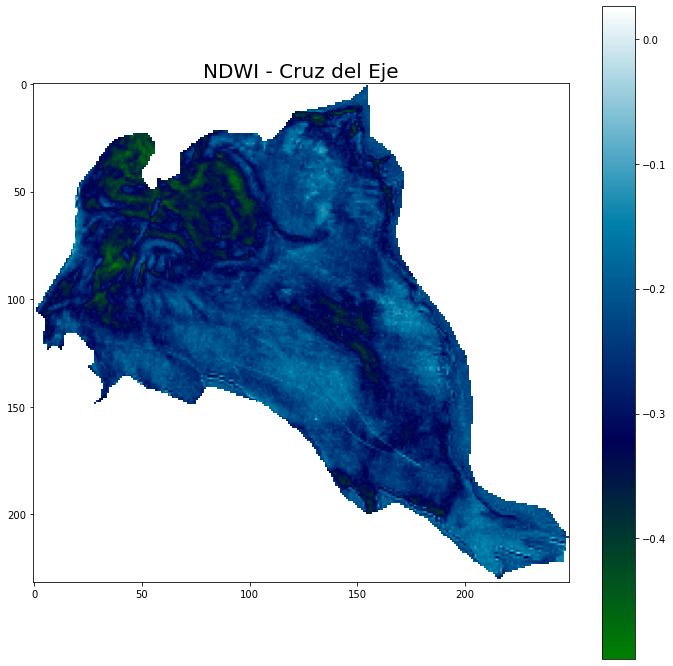

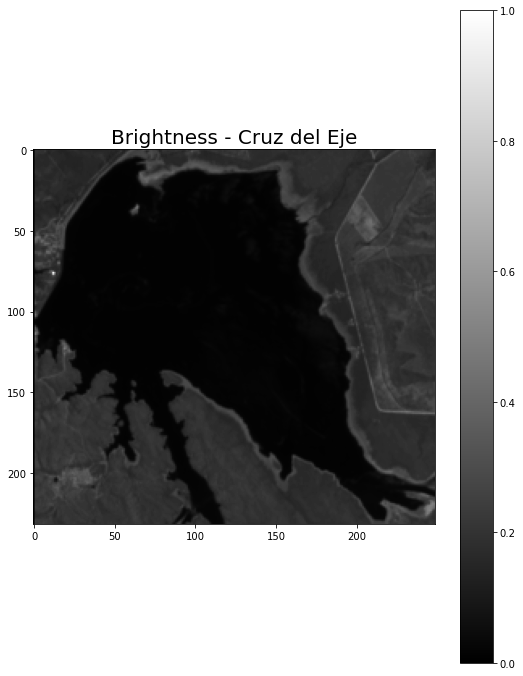

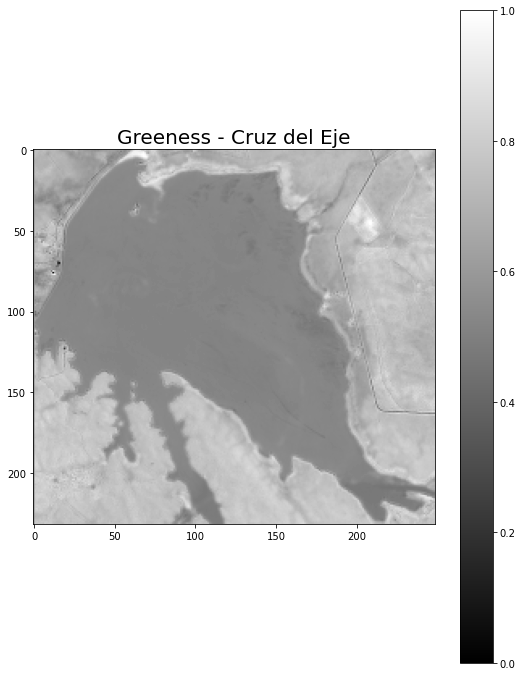

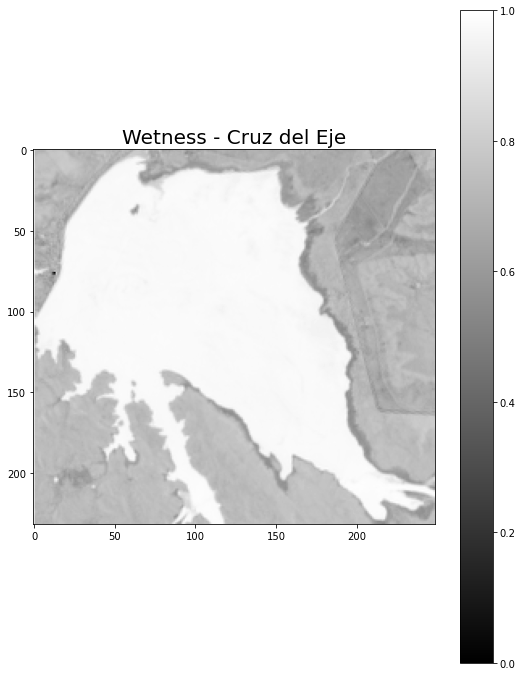

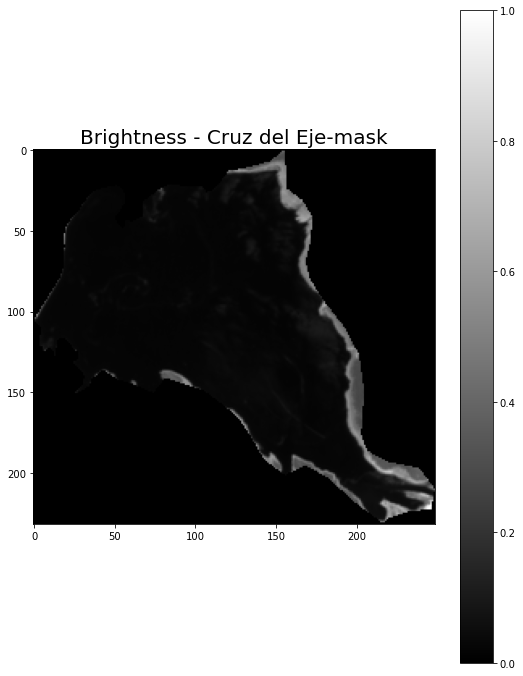

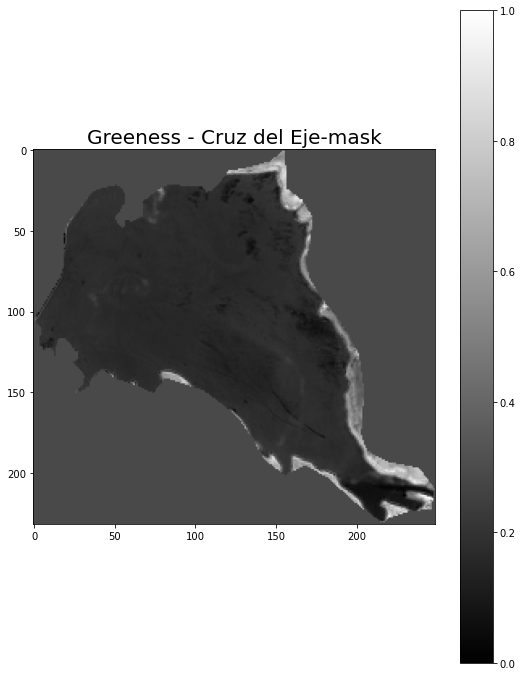

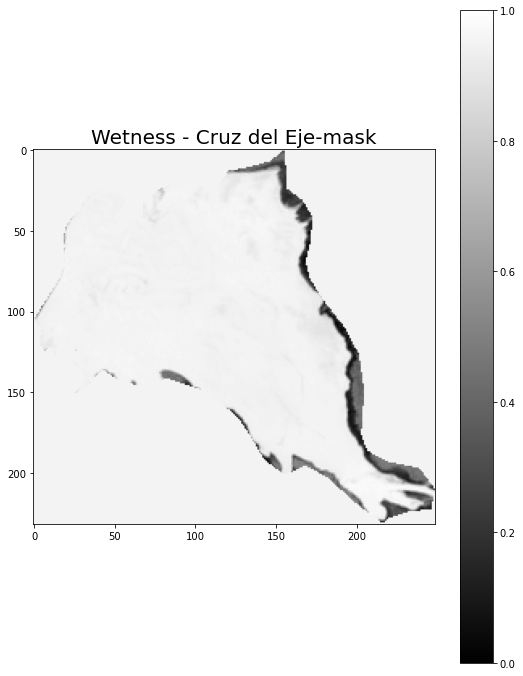

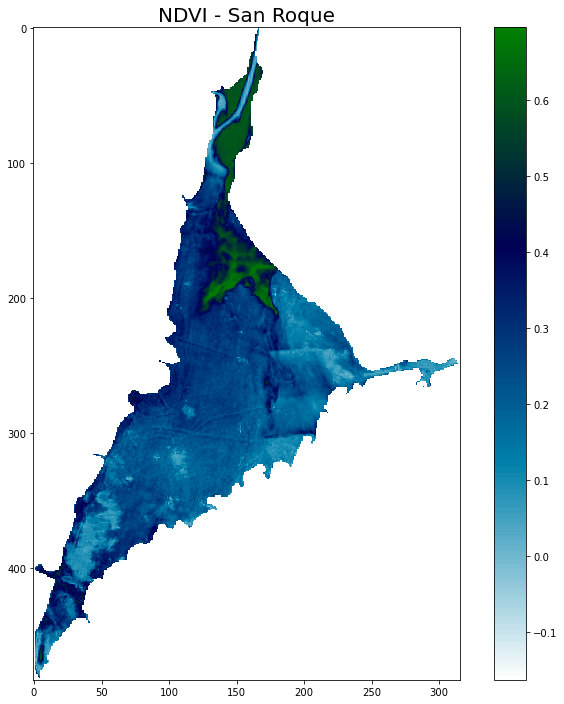

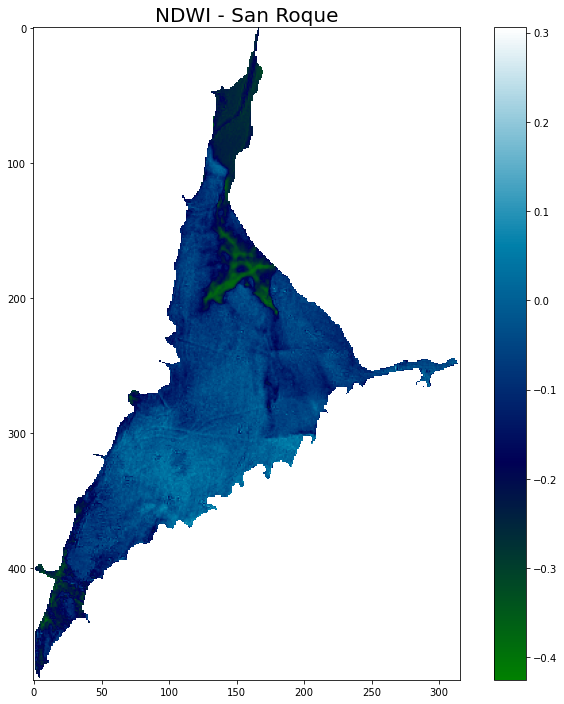

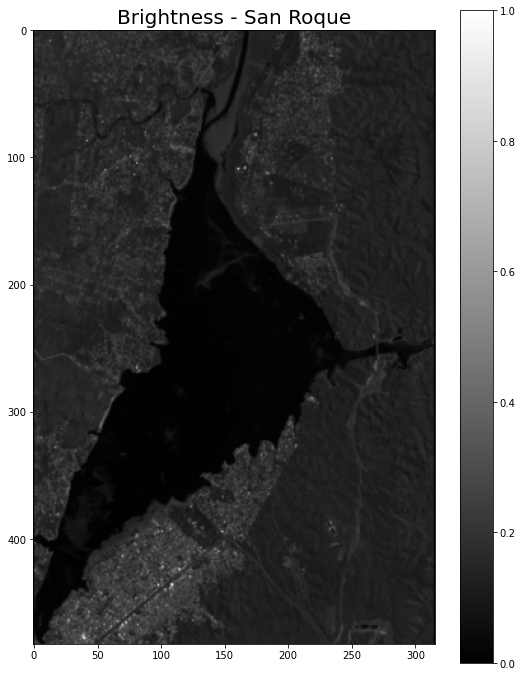

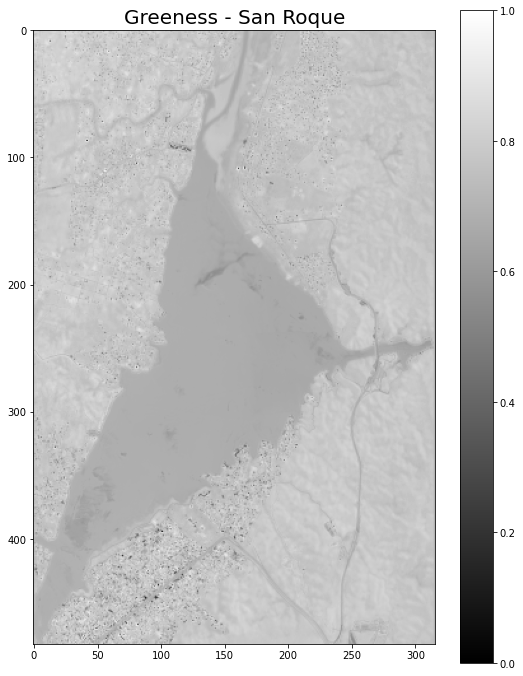

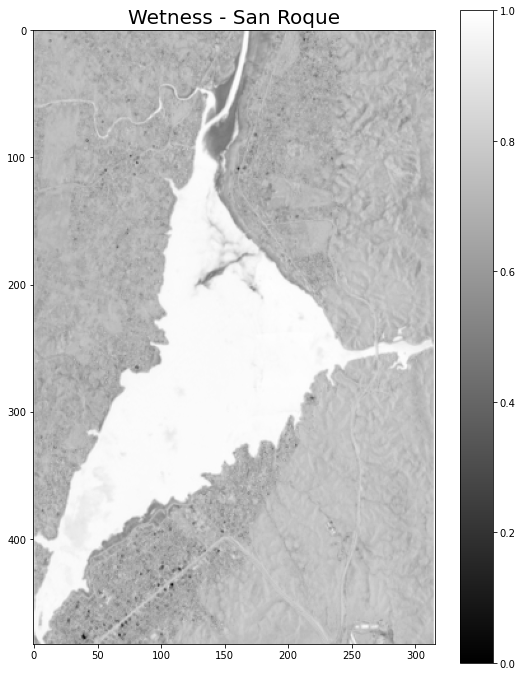

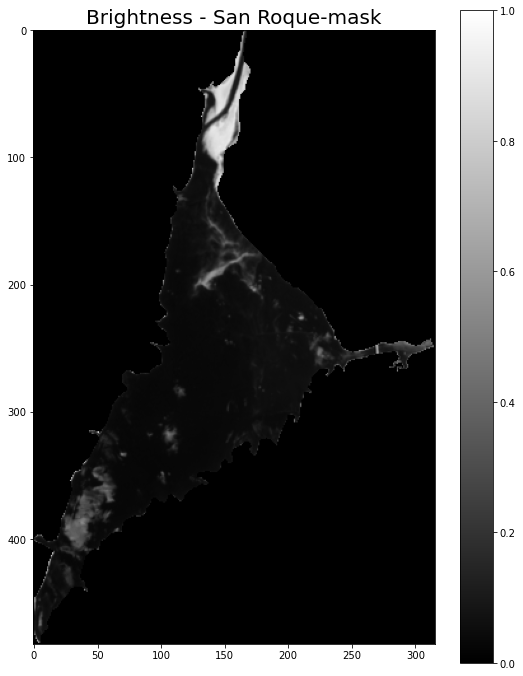

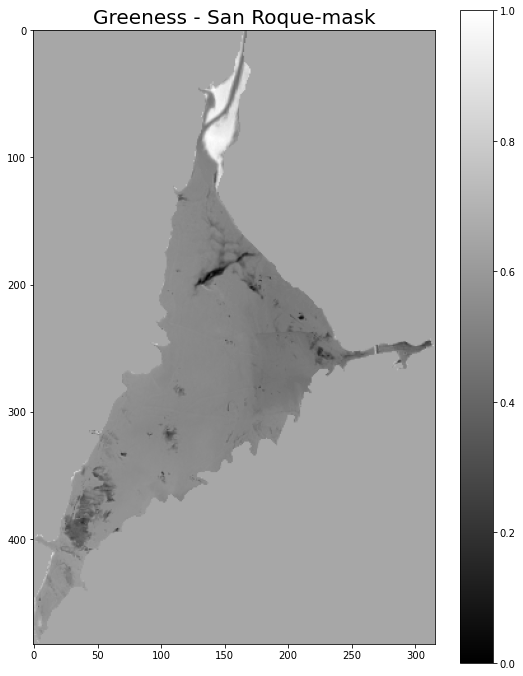

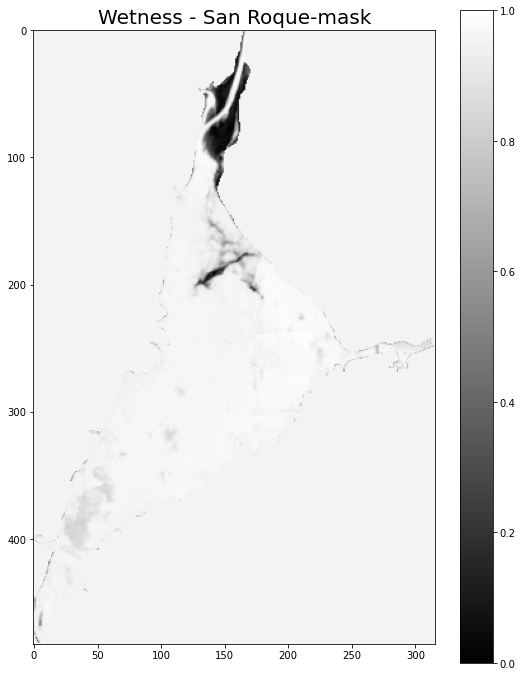

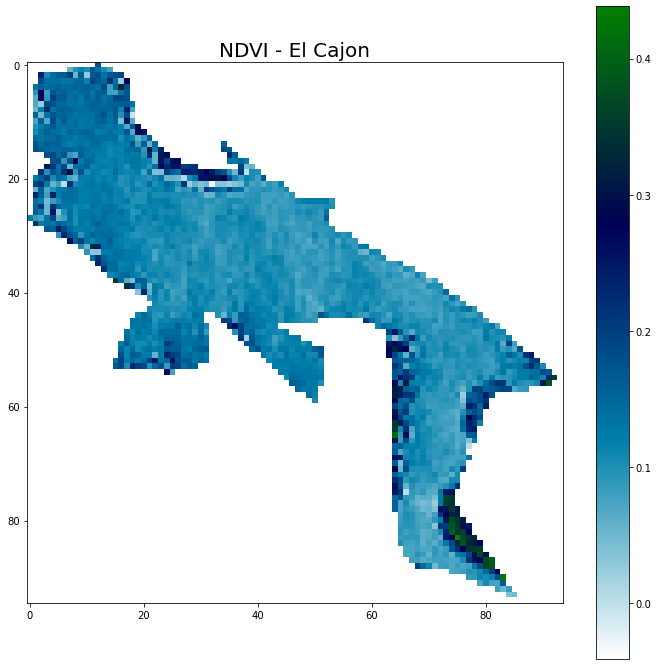

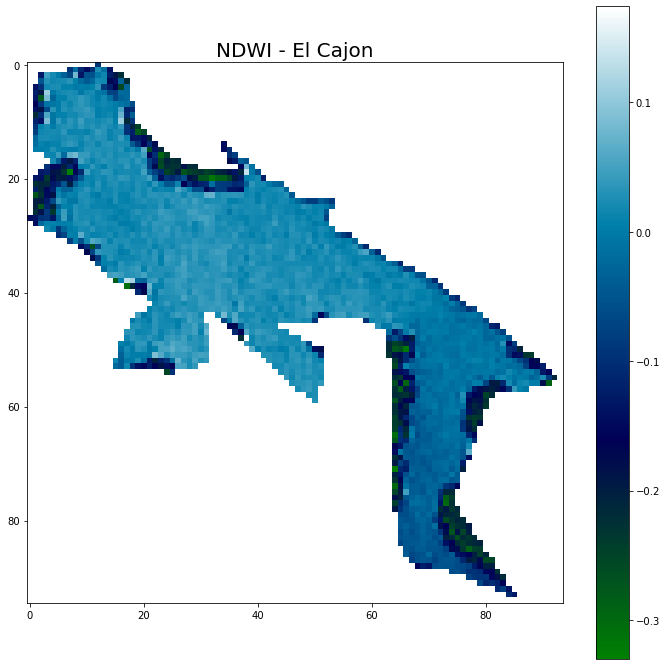

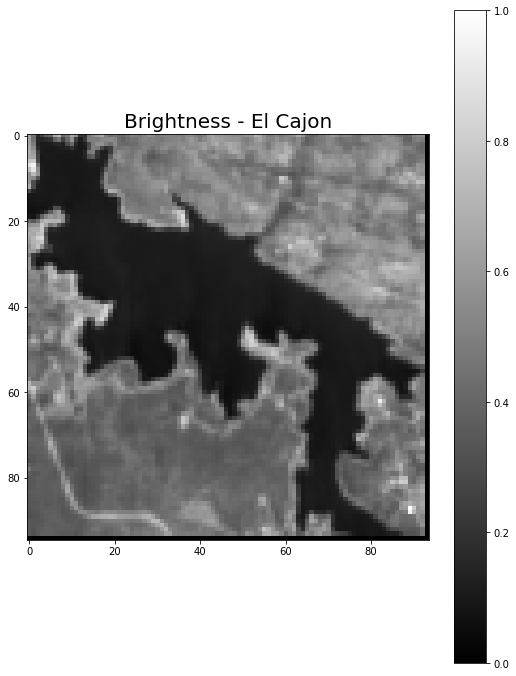

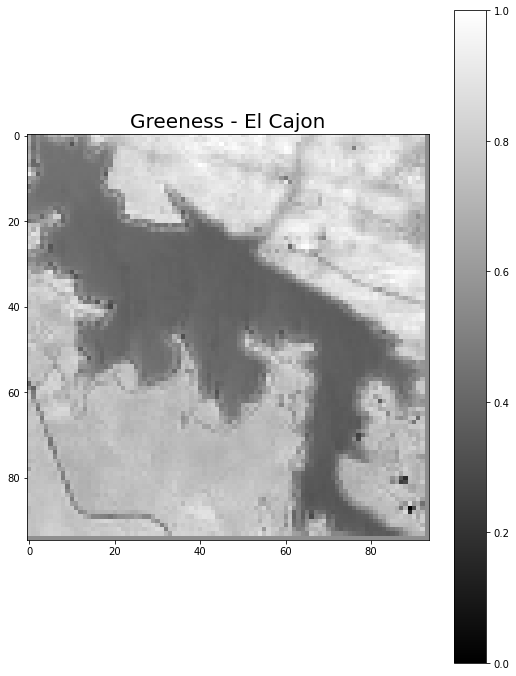

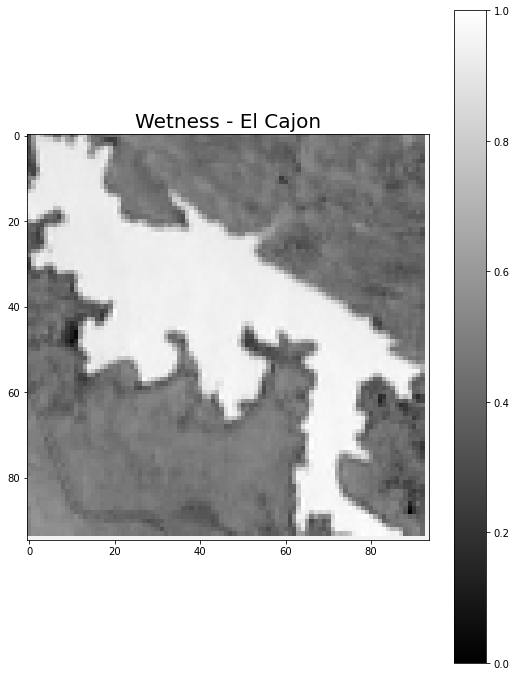

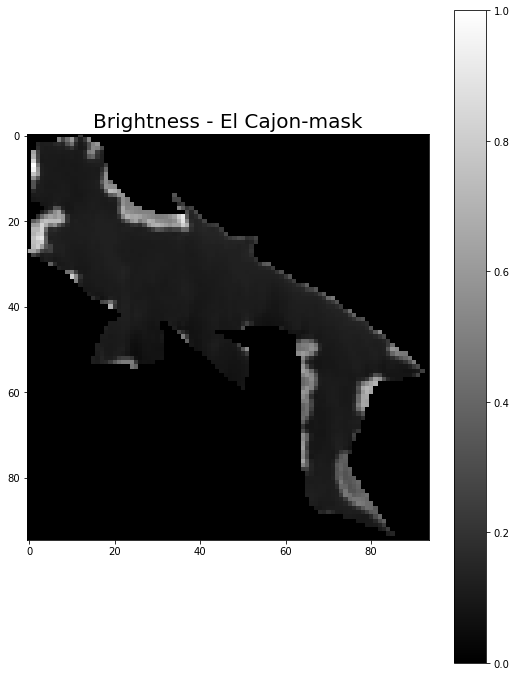

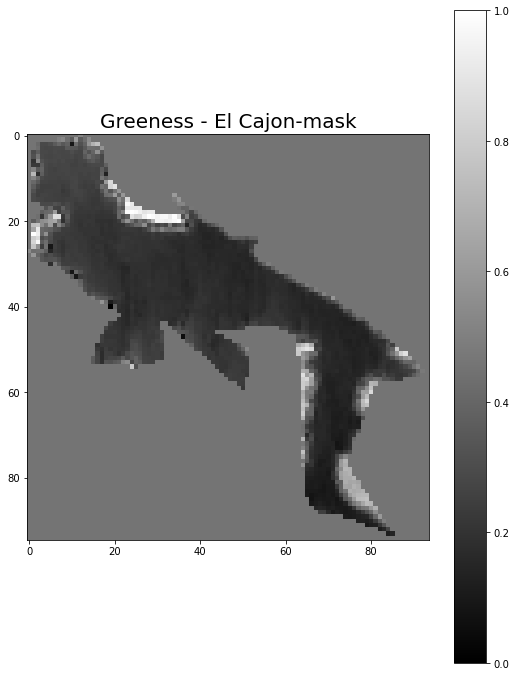

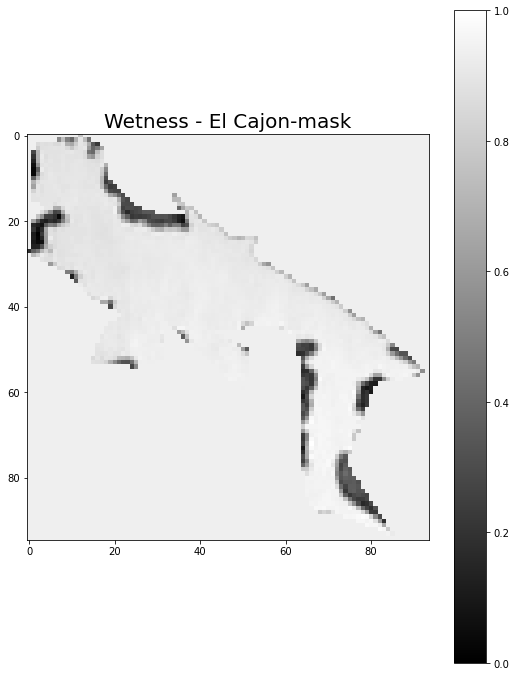

In [151]:
IDN = [4,8,10]
for ID in IDN:
    IDEmbalse = ID
    reescalado = 10000

    nombre = radios.loc[IDEmbalse].fna
    poligono = radios.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
    s2_plot_extent = plotting_extent(s2) #Bounds of the region to plot

    # CROP THE AREA OF INTEREST
    extent = poligono.envelope

    # data = [poligono, extent]
    # gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

    s2_clip, clip_transform = mask(dataset = s2, shapes = [extent], crop = True)
    s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

    os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
    # Documentos Facultad - Conicet/Cursos/Tele - UNSAM/Scipts/Plots
    plt.figure(figsize=(12,12))
    plt.imshow(indice(s2_mask,7,3,reescalado), cmap='ocean_r')  # NDVI: NIR=7, Red=3
    plt.colorbar()
    plt.title('NDVI - '+nombre,  fontsize = 20)
    plt.savefig('Plots/ndvi_'+nombre+'.png', dpi = 300)

    plt.figure(figsize=(12,12))
    plt.imshow(indice(s2_mask,2,7,reescalado), cmap='ocean')  # NDWI: Green=2, NIR=7
    plt.colorbar()
    plt.title('NDWI - '+nombre,  fontsize = 20)
    plt.savefig('Plots/ndwi_'+nombre+'.png', dpi = 300)

    os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

    indicesTC = [1,2,3,7,9,10]  # Blue, Green, Red, NIR, SWIR1, SWIR2
    matriz = []
    matriz2 = []
    coeficientesS2 = [[-0.3037, 0.2793, 0.4743, 0.5585, 0.5082, 0.1863],
                      [-0.2848, -0.2435, -0.5436, 0.7243, 0.0840, -0.1800],
                      [-0.1509, 0.1973, 0.3279, 0.3406, -0.7112, -0.4572]] 

    for i in indicesTC:
        matriz.append(s2_clip[i]/reescalado)
        matriz2.append(s2_mask[i]/reescalado)

    [brillo, verdor, humedad] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz)
    [brilloM, verdorM, humedadM] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz2)

    os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
    # nombre += '-mask'

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(brillo,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Brightness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Brightness_'+nombre+'.png', dpi = 300)

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(verdor,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Greeness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Greeness_'+nombre+'.png', dpi = 300)

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(humedad,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Wetness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Wetness_'+nombre+'.png', dpi = 300)

    os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

    os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
    nombre += '-mask'

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(brilloM,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Brightness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Brightness_'+nombre+'.png', dpi = 300)

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(verdorM,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Greeness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Greeness_'+nombre+'.png', dpi = 300)

    plt.figure(figsize = (9,12))
    plt.imshow(nequalize(humedadM,0,5), cmap='gray')
    plt.colorbar()
    plt.title('Wetness - '+nombre,  fontsize = 20)
    plt.savefig('Plots/Wetness_'+nombre+'.png', dpi = 300)

    os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

------------
Statistics
----------

In [42]:
data=pd.DataFrame({'B':blue,'G':green,'R':red,'NIR':nir})#,'NDVI':ndvi(s2_mask,2,3).flatten()})#,'clase':[clases[y] for y in Y]})

<AxesSubplot:>

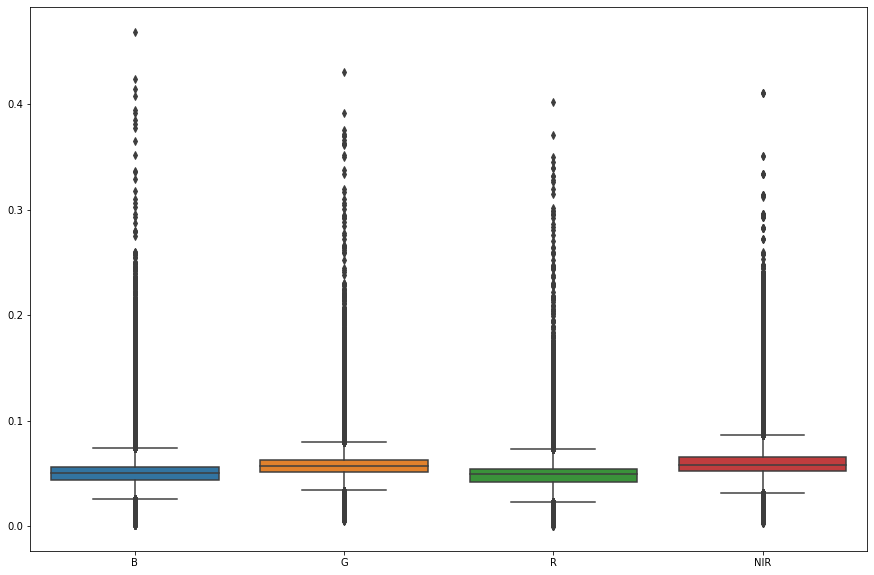

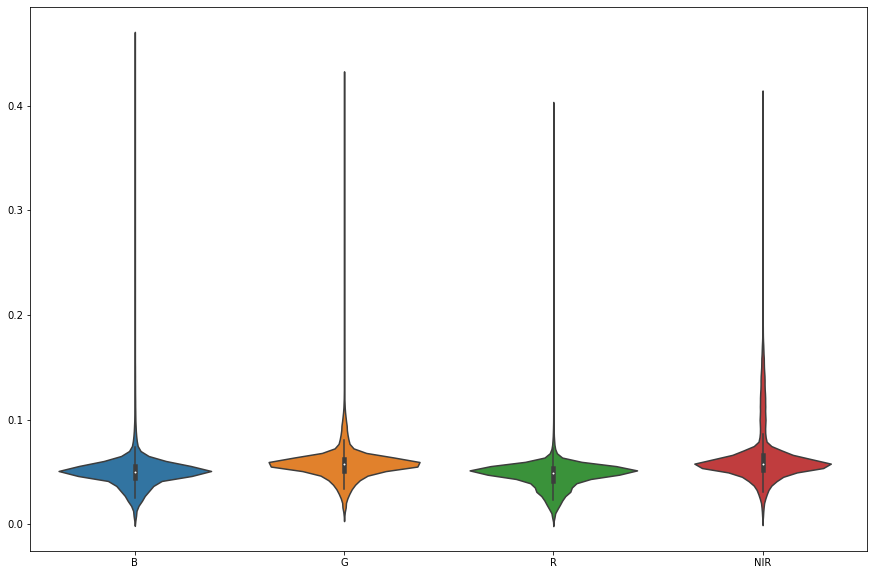

In [43]:
fig = plt.figure(figsize=(15,10))
sns.boxplot(data=data)#,x='clase', y='NDVI')
# plt.savefig('SalidasSur/boxplot.png',dpi=200)
fig = plt.figure(figsize=(15,10))
sns.violinplot(data=data)#,x='clase', y='NDVI')
# plt.savefig('SalidasSur/violinlot.png',dpi=200)

<AxesSubplot:xlabel='R', ylabel='G'>

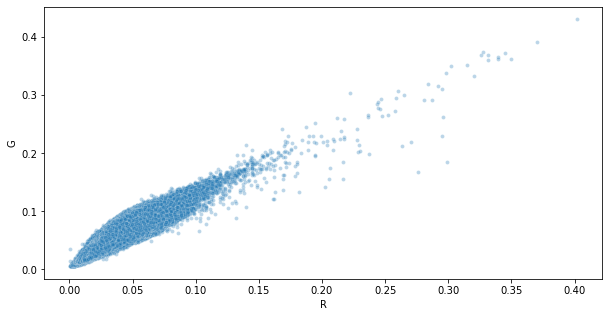

In [45]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=data, x='R', y='G', alpha=0.3, s=15)
# plt.savefig('SalidasSur/scatterplot.png')

Text(0, 0.5, 'Counts')

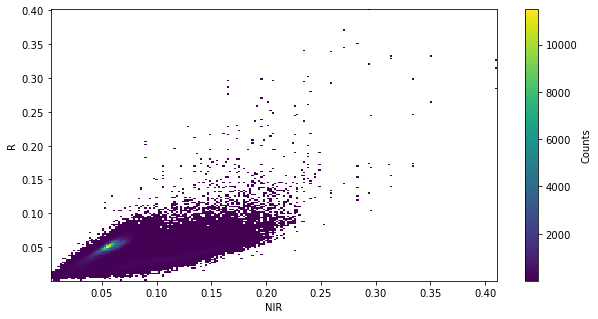

In [46]:
bandx = 'NIR'
bandy = 'R'
# Estimate the 2D histogram
nbins = 200
H, xedges, yedges = np.histogram2d(data[bandx],data[bandy],bins=nbins)
 
# H needs to be rotated and flipped
H = np.rot90(H)
H = np.flipud(H)
 
# Mask zeros
Hmasked = np.ma.masked_where(H==0,H) # Mask pixels with a value of zero
 
# Plot 2D histogram using pcolor
fig2 = plt.figure(figsize=(10,5))
# sns.jointplot(data=data, x=bandx, y=bandy)l<
plt.pcolormesh(xedges,yedges,Hmasked)
plt.xlabel(bandx)
plt.ylabel(bandy)
cbar = plt.colorbar()
cbar.ax.set_ylabel('Counts')

In [ ]:
plt.figure()
sns.jointplot(data=data, x=bandx, y=bandy, kind='kde', fill=True)
plt.savefig('SalidasSur/scatterplot.png',dpi=200)

In [28]:
blue.shape

(464284,)

In [103]:
bluee = s2_mask[1]/10000
greenn = s2_mask[2]/10000
redd = s2_mask[3]/10000
nirr = s2_mask[7]/10000

redd[redd == 0] = np.nan
greenn[greenn == 0] = np.nan
bluee[bluee == 0] = np.nan
nirr[nirr == 0] = np.nan 

# plt.hist(redd[np.isfinite(redd)], 50);
# plt.hist(redd.flatten(), 50);

In [24]:
bluee = s2_mask[1]/10000
greenn = s2_mask[2]/10000
redd = s2_mask[3]/10000
nirr = s2_mask[7]/10000

bluee2 = bluee[(bluee!=0)]
greenn2 = greenn[greenn!=0]
redd2 = redd[redd!=0]
nirr2 = nirr[nirr!=0]

In [116]:
np.where(bluee2 == np.max(bluee2))

(array([350304], dtype=int64),)

In [117]:
max(bluee2)

0.199

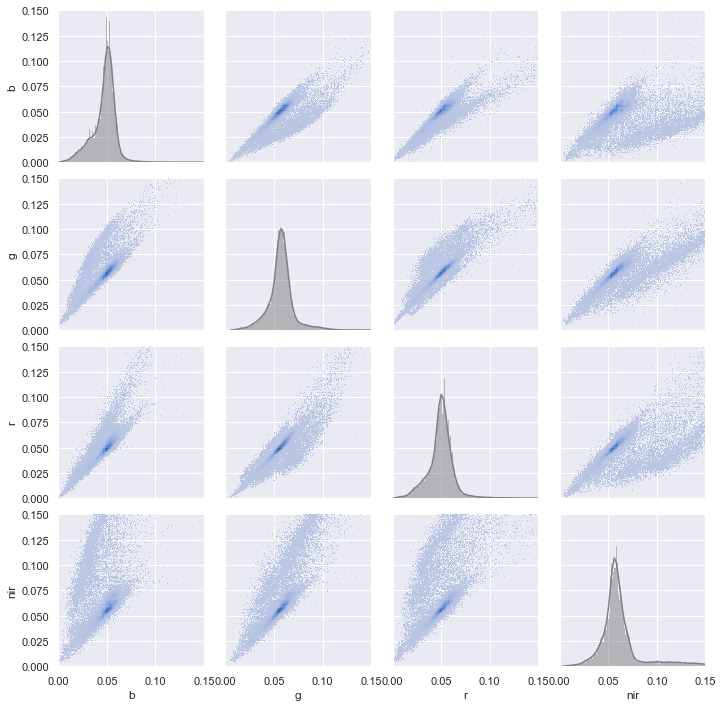

In [125]:
# stack_data = np.stack((bluee[np.isfinite(bluee)],greenn[np.isfinite(greenn)],redd[np.isfinite(redd)],nirr[np.isfinite(nirr)])).T
stack_data2 = np.stack((bluee2, greenn2, redd2, nirr2)).T
data = pd.DataFrame(stack_data2, columns = ['b','g','r','nir'])

f = sns.PairGrid(data)
# f.fig.suptitle(Nombre, y=1.01, fontsize = 'large')
f.map_upper(sns.histplot)
f.map_lower(sns.histplot)
f.map_diag(sns.histplot, kde=True, color='.5')
f.set(xlim = (0,0.15), ylim = (0,0.15))

In [25]:
# stack_data = np.stack((bluee[np.isfinite(bluee)],greenn[np.isfinite(greenn)],redd[np.isfinite(redd)],nirr[np.isfinite(nirr)])).T
stack_data2 = np.stack((bluee2, greenn2, redd2, nirr2)).T
data = pd.DataFrame(stack_data2, columns = ['b','g','r','nir'])

# f = sns.PairGrid(data)
# # f.fig.suptitle(Nombre, y=1.01, fontsize = 'large')
# f.map_upper(sns.kdeplot, fill = True)
# f.map_lower(sns.histplot)
# f.map_diag(sns.histplot, kde=True, color='.5')
# f.set(xlim = (0,0.15), ylim = (0,0.15))

In [26]:
S = np.zeros((6,6))
b_mean = np.mean(data['b'])

,b,g,r,nir
0,0.0272,0.0550,0.0342,0.0844
1,0.0250,0.0526,0.0316,0.0775
2,0.0239,0.0519,0.0308,0.0844
3,0.0300,0.0582,0.0344,0.0844
4,0.0175,0.0399,0.0219,0.0710
...,...,...,...,...
464279,0.0281,0.0380,0.0354,0.0657
464280,0.0242,0.0459,0.0315,0.0780
464281,0.0248,0.0502,0.0349,0.0780
464282,0.0298,0.0393,0.0377,0.0657


In [27]:
data.mean

<bound method NDFrame._add_numeric_operations.<locals>.mean of              b       g       r     nir
0       0.0272  0.0550  0.0342  0.0844
1       0.0250  0.0526  0.0316  0.0775
2       0.0239  0.0519  0.0308  0.0844
3       0.0300  0.0582  0.0344  0.0844
4       0.0175  0.0399  0.0219  0.0710
...        ...     ...     ...     ...
464279  0.0281  0.0380  0.0354  0.0657
464280  0.0242  0.0459  0.0315  0.0780
464281  0.0248  0.0502  0.0349  0.0780
464282  0.0298  0.0393  0.0377  0.0657
464283  0.0254  0.0494  0.0315  0.0808

[464284 rows x 4 columns]>

<AxesSubplot:xlabel='r', ylabel='b'>

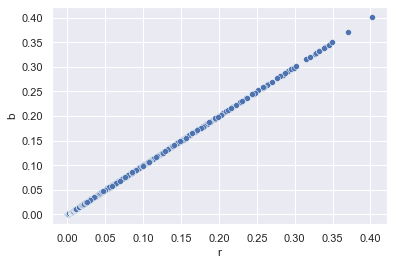

In [102]:
sns.scatterplot(data = data, x = 'r', y = 'b')